# Phase 4 — Unsupervised GraphSAGE Embeddings

**Mục tiêu:** dựng multi-relational graph snapshot (geo / facility / ZIP / history), train Unsupervised GraphSAGE trên **CUDA**, visualize loss, lưu weights + embeddings.

**Leakage safety:** chỉ dùng inspections **strictly before** cutoff `2016-12-31`. Labels không tham gia loss.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml

REPO = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

from food_safety_gnn.graph_builder import GraphBuildConfig, build_snapshot
from food_safety_gnn.graphsage import GraphSAGEConfig, require_cuda, train_unsupervised_graphsage
from food_safety_gnn.viz import apply_project_style, line_chart, SERIES

apply_project_style()
PHASE3 = REPO / 'data' / 'interim' / 'phase3' / 'v1'
CONFIG_PATH = REPO / 'configs' / 'phase4' / 'graphsage_v1.yaml'
cfg = yaml.safe_load(CONFIG_PATH.read_text(encoding='utf-8'))
OUTPUT_DIR = REPO / cfg['output_directory']
print('phase3 exists:', PHASE3.exists())
print('config:', CONFIG_PATH)


phase3 exists: True
config: /home/jkl/Code/BTL-MH/configs/phase4/graphsage_v1.yaml


## 1. CUDA preflight

In [2]:
print('torch:', torch.__version__)
print('torch cuda build:', torch.version.cuda)
print('cuda available:', torch.cuda.is_available())
device = require_cuda(cfg['training']['device'])
print('selected device:', device)
print('gpu name:', torch.cuda.get_device_name(device))


torch: 2.11.0+cu128
torch cuda build: 12.8
cuda available: True


selected device: cuda:0
gpu name: NVIDIA GeForce RTX 5070 Ti


## 2. Load Phase 3 artifacts & build temporal graph snapshot

In [3]:
canonical = pd.read_parquet(PHASE3 / 'canonical_inspections.parquet')
violations = pd.read_parquet(PHASE3 / 'violation_code_events.parquet')
print('canonical rows:', len(canonical))
print('violation events:', len(violations))

graph_cfg = GraphBuildConfig(
    geo_k=cfg['snapshot']['geo_k'],
    geo_radius_m=cfg['snapshot']['geo_radius_m'],
    facility_peer_cap=cfg['snapshot']['facility_peer_cap'],
    zip_peer_cap=cfg['snapshot']['zip_peer_cap'],
    history_k=cfg['snapshot']['history_k'],
    history_dim=cfg['snapshot']['history_dim'],
    max_nodes=cfg['snapshot'].get('max_nodes'),
    seed=cfg['training']['seed'],
)
snapshot = build_snapshot(
    canonical=canonical,
    violation_events=violations,
    cutoff=cfg['snapshot']['cutoff'],
    config=graph_cfg,
    output_directory=OUTPUT_DIR / 'graph',
)
print(json.dumps(snapshot['diagnostics'], indent=2))
snapshot['state'][['entity_id', 'Facility Type', 'Zip', 'prior_inspection_count', 'prior_fail_rate']].head()


canonical rows: 196676
violation events: 618457


{
  "cutoff": "2016-12-31",
  "num_nodes": 8000,
  "feature_dim": 200,
  "relations": {
    "geo": {
      "num_edges": 60909,
      "avg_degree": 7.613625
    },
    "facility": {
      "num_edges": 107524,
      "avg_degree": 13.4405
    },
    "zip": {
      "num_edges": 123332,
      "avg_degree": 15.4165
    },
    "history": {
      "num_edges": 34288,
      "avg_degree": 4.286
    }
  },
  "created_at": "2026-07-15T17:06:08+00:00",
  "config": {
    "geo_k": 8,
    "geo_radius_m": 750,
    "facility_peer_cap": 8,
    "zip_peer_cap": 8,
    "history_k": 8,
    "history_dim": 24,
    "max_nodes": 8000,
    "seed": 42
  }
}


,entity_id,Facility Type,Zip,prior_inspection_count,prior_fail_rate
0,0005e72169f87706f71b,None,60646.0,1,0.000000
1,000ba072340e694fc94d,Grocery Store,60623.0,3,0.333333
2,0012813c934629a11b64,Restaurant,60622.0,3,0.333333
3,002021e7a720d767c01c,None,60605.0,1,0.000000
4,0026d89ec4edfa661239,None,60625.0,1,0.000000


## 3. Relation edge counts

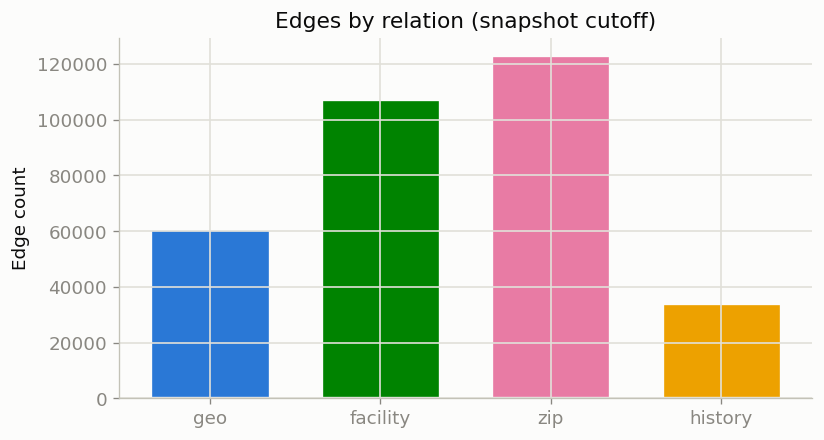

,num_edges,avg_degree
geo,60909.0,7.613625
facility,107524.0,13.440500
zip,123332.0,15.416500
history,34288.0,4.286000


In [4]:
rel = snapshot['diagnostics']['relations']
fig, ax = plt.subplots(figsize=(7, 3.8))
names = list(rel.keys())
values = [rel[n]['num_edges'] for n in names]
ax.bar(names, values, color=SERIES[: len(names)], width=0.7, edgecolor='#fcfcfb', linewidth=2)
ax.set_title('Edges by relation (snapshot cutoff)')
ax.set_ylabel('Edge count')
fig.tight_layout()
plt.show()
pd.DataFrame(rel).T


## 4. Train Unsupervised GraphSAGE on GPU

In [5]:
train_cfg = GraphSAGEConfig(
    embedding_dim=cfg['training']['embedding_dim'],
    hidden_dim=cfg['training']['hidden_dim'],
    num_layers=cfg['training']['num_layers'],
    learning_rate=cfg['training']['learning_rate'],
    epochs=cfg['training']['epochs'],
    batch_size=cfg['training']['batch_size'],
    num_negatives=cfg['training']['num_negatives'],
    seed=cfg['training']['seed'],
    device=cfg['training']['device'],
)
result = train_unsupervised_graphsage(
    features=snapshot['x'],
    edge_index=snapshot['edge_index'],
    config=train_cfg,
    output_directory=OUTPUT_DIR,
    entity_ids=snapshot['state']['entity_id'].tolist(),
    cutoff=cfg['snapshot']['cutoff'],
)
print('device:', result['device'])
print('gpu:', result['gpu_name'])
print('final loss:', result['final_loss'])
print('embeddings:', result['embeddings_path'])
print('weights:', result['weights_path'])


device: cuda:0
gpu: NVIDIA GeForce RTX 5070 Ti
final loss: 0.6846494674682617
embeddings: /home/jkl/Code/BTL-MH/artifacts/phase4/v1/entity_embeddings.parquet
weights: /home/jkl/Code/BTL-MH/artifacts/phase4/v1/graphsage_weights.pt


## 5. Training loss curve

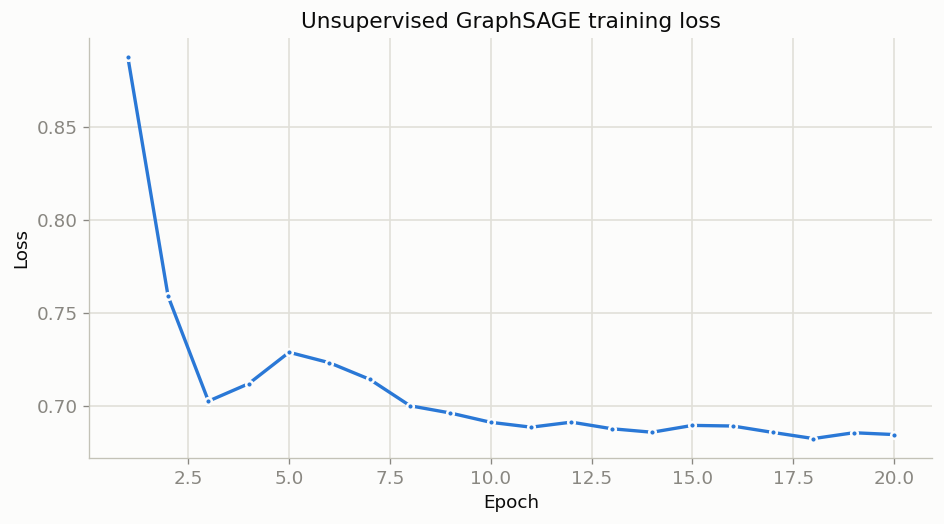

,epoch,loss
15,16,0.689239
16,17,0.685772
17,18,0.682496
18,19,0.685629
19,20,0.684649


In [6]:
history = pd.DataFrame(result['history'])
fig, ax = line_chart(
    history['epoch'],
    history['loss'],
    title='Unsupervised GraphSAGE training loss',
    xlabel='Epoch',
    ylabel='Loss',
    color=SERIES[0],
)
plt.show()
history.tail()


## 6. Embedding preview

In [7]:
embeddings = pd.read_parquet(OUTPUT_DIR / 'entity_embeddings.parquet')
print('embedding shape:', embeddings.shape)
print('cutoff:', embeddings['snapshot_cutoff'].iloc[0])
print('embedding dim:', embeddings.filter(like='emb_').shape[1])
embeddings.head()


embedding shape: (8000, 66)
cutoff: 2016-12-31
embedding dim: 64


,entity_id,snapshot_cutoff,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,0005e72169f87706f71b,2016-12-31,0.051828,0.086656,-0.022378,0.097000,0.044012,-0.018231,-0.454633,-0.069385,...,0.087269,0.108573,0.100963,0.159735,0.069440,-0.137340,-0.005382,-0.035780,0.057815,0.021146
1,000ba072340e694fc94d,2016-12-31,0.140586,-0.054621,-0.116646,-0.175274,-0.023764,0.054189,0.168594,0.093255,...,-0.278045,-0.021251,-0.073963,-0.039158,-0.094923,0.116651,-0.129281,-0.113144,-0.029859,0.111726
2,0012813c934629a11b64,2016-12-31,0.014394,0.090291,0.174465,-0.207258,-0.024594,0.045956,0.002396,-0.084953,...,-0.041431,-0.094699,-0.218525,0.208494,0.001482,-0.190015,-0.111182,-0.080707,0.109455,-0.115152
3,002021e7a720d767c01c,2016-12-31,0.079311,0.066582,-0.082657,0.001759,0.036088,0.046047,0.019369,0.022420,...,0.159969,-0.005138,0.103182,-0.157825,0.091392,-0.023436,0.068338,0.121891,0.077545,-0.229094
4,0026d89ec4edfa661239,2016-12-31,0.058141,-0.068233,-0.072494,0.199772,0.023226,0.068478,-0.394020,-0.065534,...,-0.099718,0.184387,-0.049685,0.138708,0.024315,-0.135855,-0.161658,-0.105824,-0.021732,0.232229
